In [28]:
#imports
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks 
from scipy.stats import linregress
import math
import numpy as np

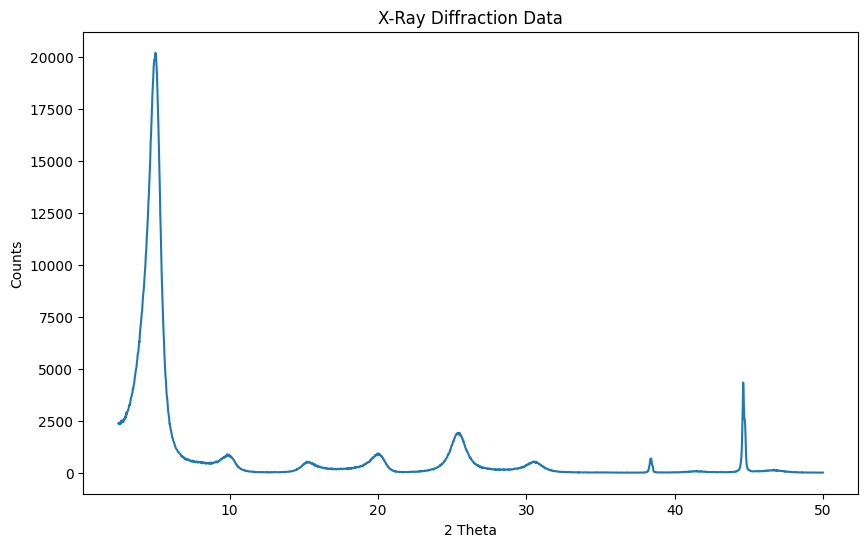

In [6]:
#origonal plot (plain)
df = pd.read_csv('/Users/carolinecarr/64labs/xraydiff.csv')
y_data = df.iloc[:, 1]  
x_data = df.iloc[:, 0]  

plt.figure(figsize=(10, 6))
plt.plot(x_data, y_data)

plt.ylabel(df.columns[1])
plt.xlabel(df.columns[0]) 
plt.title('X-Ray Diffraction Data')

plt.show()


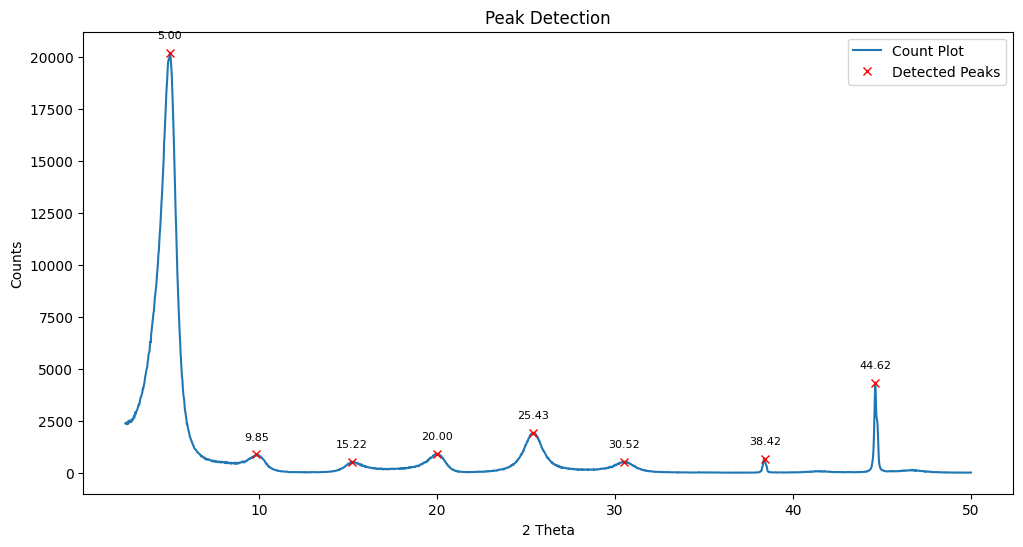

Peak angles
[ 5.     9.85  15.225 20.    25.425 30.525 38.425 44.625]


In [11]:

peaks, properties = find_peaks(y, height=500, distance=60,prominence=50)

plt.figure(figsize=(12, 6))
plt.plot(x, y, label='Count Plot')
plt.plot(x[peaks], y[peaks], "rx", label='Detected Peaks')

for i, txt in enumerate(x[peaks]):
    plt.annotate(f"{txt:.2f}", (x[peaks].iloc[i], y[peaks].iloc[i]), 
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)

plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.title('Peak Detection')
plt.legend()
plt.show()

print("Peak angles")
print(x[peaks].values)

1.7652700932061078
0.8968959551981808
0.581252112619617
0.44342532720205985
0.34990611741937655
0.29250685700413026
0.23399086903693053
0.2028141116771083


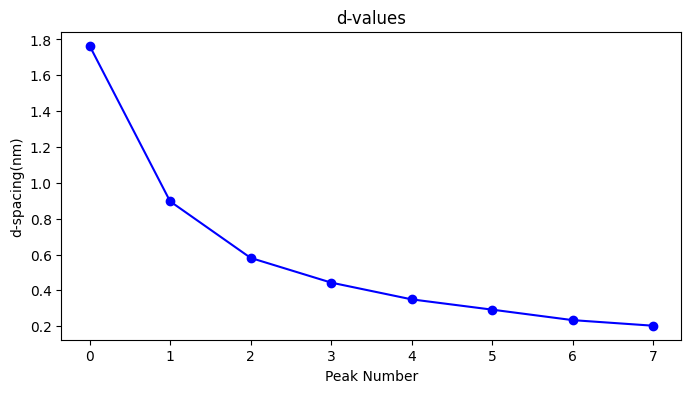

In [25]:
#d values
d_values = [] #nanometers
for i, theta in enumerate(x[peaks]):
    angle_radians = math.radians(theta)
    sintheta = math.sin((angle_radians/2))
    d = 0.154/(2*sintheta)
    print(d)
    d_values.append(d)

plt.figure(figsize=(8, 4))
plt.plot(d_values, 'o-', color='blue')
plt.ylabel('d-spacing(nm)')
plt.xlabel('Peak Number')
plt.title('d-values')
plt.show()

In [22]:
#spacing ratio
d1 = d_values[0]
for i, d in enumerate(d_values):
    ratio = d1 / d if d > 0 else 0
    print(ratio)

1.0
1.9681994137391874
3.037012777898213
3.980986165911336
5.044982083266525
6.034969953477644
7.544183670378596
8.703881986360589


1.8494401017489646
Individual d1 [1.76527009 1.79379191 1.74375634 1.77370131 1.74953059 1.75504114
 1.87192695 1.82532701]


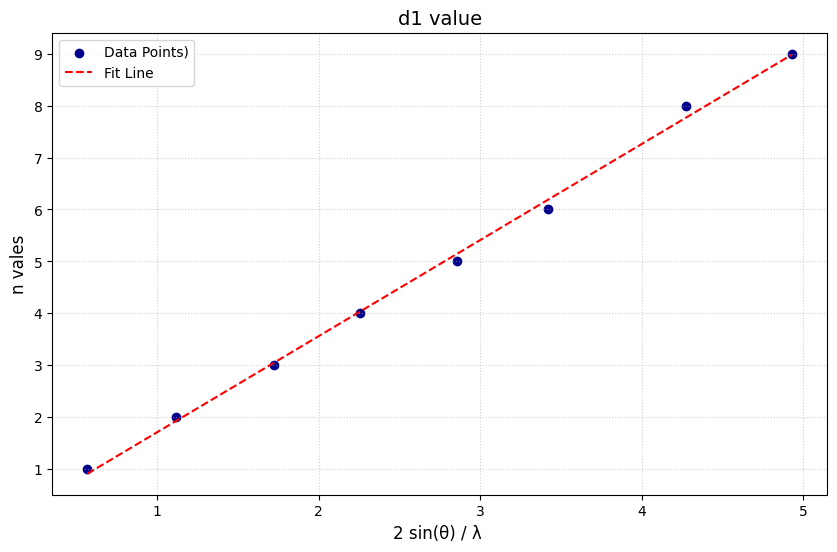

In [37]:
twotheta = x[peaks].values
n_vals = np.array([1, 2, 3, 4, 5, 6, 8, 9]) 

thetar = np.radians(twotheta / 2)
ratios = (2 * np.sin(thetar)) / .154

slope, intercept, r_value, p_value, std_err = linregress(ratios, n_vals)


plt.figure(figsize=(10, 6))
plt.scatter(ratios, n_vals, color='darkblue', label='Data Points)')

fit_line = slope * ratios + intercept
plt.plot(ratios, fit_line, color='red', linestyle='--', label=f'Fit Line')


plt.title('d1 value', fontsize=14)
plt.xlabel('2 sin(θ) / λ ', fontsize=12)
plt.ylabel('n vales', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()


print(slope)

d1_solo = d_values * n_vals

print(f"Individual d1 {d1_solo}")

plt.show()

d1: 1.7474887627103746
Individual d1: 1.7635


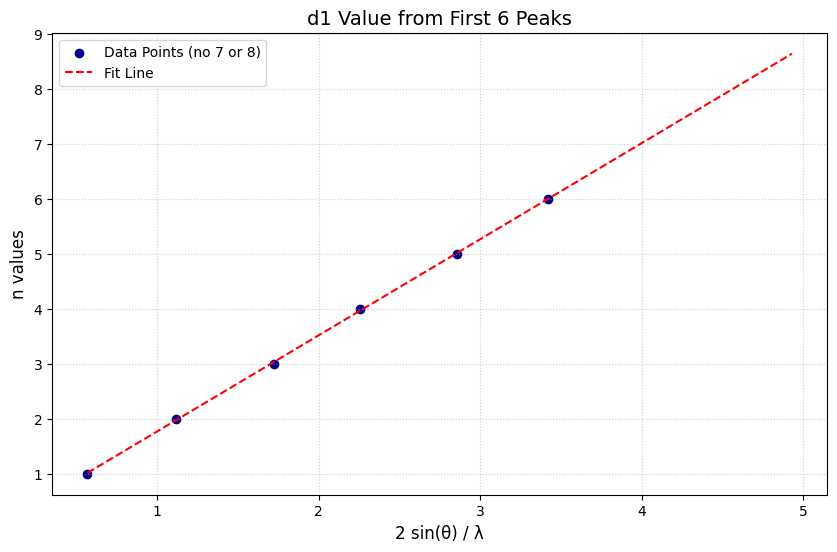

In [ ]:
sv_subset = ratios[:-2]
n_subset = n_vals[:-2]

slope, intercept, r_value, p_value, std_err = linregress(sv_subset, n_subset)

plt.figure(figsize=(10, 6))
plt.scatter(ratios[:-2], n_vals[:-2], color='darkblue', label='Data Points (no 7 or 8)')

fit_line = slope * ratios + intercept
plt.plot(ratios, fit_line, color='red', linestyle='--', label=f'Fit Line')

plt.title('d1 Value from First 6 Peaks', fontsize=14)
plt.xlabel('2 sin(θ) / λ', fontsize=12)
plt.ylabel('n values', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

print(f"d1: {slope}")

d1_solo2 = (d_values[:-2] * n_vals[:-2])
print(f"Individual d1: {np.mean(d1_solo2):.4f}")

plt.show()